In [1]:
print("Everything is working fine!")

Everything is working fine!


##### Simple chatbot in Langchain

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]= os.getenv("GOOGLE_API_KEY")

from langchain_google_genai import GoogleGenerativeAI

llm = GoogleGenerativeAI(model="gemini-2.5-flash")

d:\GENAIBatch\langchain_new\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
while True:
    
    query = input("Enter your query (or 'exit' to quit): ")
    if query.lower() == 'exit':
        print("Exiting the program. Goodbye!")
        break
    
    response = llm.invoke(query)
    print("User: ", query)
    print("Response:", response)

User:  hi
Response: Hi there! How can I help you today?
User:  5 plus 5
Response: 5 plus 5 equals **10**.
User:  bye
Response: Goodbye! Have a great day.
Exiting the program. Goodbye!


#### Create a simple agent using langchain


In [4]:
from langchain.agents import create_agent

agent = create_agent(
    model = llm,
    tools = [],
    system_prompt = "You are a helpful assistant that provides accurate and concise answers to user queries.")

while True:
    query = input("Enter your query (or 'exit' to quit): ")
    if query.lower() == 'exit':
        print("Exiting the program. Goodbye!")
        break
    
    response = agent.invoke({"user": query})
    print("User: ", query)
    print("Response:", response["messages"][0].content)


User:  hi
Response: Understood. I will provide accurate and concise answers to your queries.
User:  tell me about today's IPL match
Response: Understood. I will provide accurate and concise answers to user queries.
Exiting the program. Goodbye!


In [5]:
# print graph
print(agent.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
  +-------+    
  | model |    
  +-------+    
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


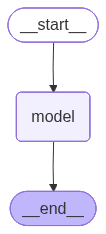

In [6]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

#### Creating simple chatbot from langgraph

- State